In [3]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

# Mean-Variance Portfolio Optimization and Efficient Frontier Analysis
---

## 1. Introduction

Portfolio optimization is a fundamental problem in quantative finance.
The goal is to allocate capital across multiple assets in a way that optimizes the tradeoff between expected return and risk.

In this project, we study a portfolio composed of 8 US stocks.
Although the assets are denominated in USD, performance will be evaluated from the perspective of a EUR-based investor.

We allow short-selling and include a risk-free asset in order to construct:

- The Global Minimum Variance Portfolio
- The Efficient Frontier
- The Maximum Sharpe (Tangency) Portfolio

The results will be compared against a simple equal-weight benchmark portfolio.


## 2. Research question

This project investigates how mean-variance portfolio optimization with short-selling performs relative to an equal-weight portfolio for a set of 8 US stocks, when evaluated of the perspective of a EUR-based investor including risk-free asset.

## 3. Assets

The portfolio consists of 8 large-cap US stocks across different sectors:

- Technology: AAPL, MSFT
- Healthcare: JNJ, PFE
- Consumer: KO, WMT
- Energy: XOM
- Finance: JPM

This diversified sector exposure allows meaningful covariance structure analysis and realistic portfolio construction.

## 4. Data description

We use 5 years of historical daily price data for the selected 8 US stocks

- Frequency: Daily
- Data type: Adjusted Close prices
- Period: Last 5 years
- Currency of assets: USD
- Base evaluation currency: EUR

Daily returns will be computed from adjusted closing prices.
The analysis will use log-returns for mathematical consistency.


## 5. Data download and currency conversion

We download 5 years of daily adjusted closing prices for the selected US stocks.

Since the assets are denominated in USD but evaluated from a EUR-based investor perspective, we convert prices into EUR using the EUR/USD exchange rate.


In [4]:
# Defining tickers
tickers = ["AAPL", "MSFT", "JNJ", "PFE", "KO", "WMT", "XOM", "JPM"]
fx_ticker = "EURUSD=X"

# Defining 5 years date range
end_date = pd.Timestamp.today().normalize()
start_date = end_date - pd.DateOffset(years=5)

# Downloading stock prices in USD and extracting close prices
stocks_raw = yf.download(tickers, start=start_date, end=end_date, progress=False)
prices_usd = stocks_raw['Close'].dropna(how='all')

# Downloading EUR/USD rate
fx_raw = yf.download(fx_ticker, start=start_date, end=end_date, progress=False)
eurusd = fx_raw[("Close", fx_ticker)].dropna()

# Converting USD prices to EUR
eur_per_usd = 1 / eurusd
data = prices_usd.join(eur_per_usd.rename("EUR_per_USD"), how="inner")
prices_eur = data[tickers].mul(data["EUR_per_USD"], axis=0).dropna()

prices_eur.head()


,AAPL,MSFT,JNJ,PFE,KO,WMT,XOM,JPM
Date,,,,,,,,
2021-03-03,98.370952,180.677640,112.249448,22.168018,35.580087,32.879117,38.614808,111.420316
2021-03-04,97.095163,180.538612,110.303764,22.109222,35.654286,32.958563,40.226879,110.024803
2021-03-05,98.817794,185.694301,113.266643,22.386095,36.512401,33.600710,42.037255,111.044711
2021-03-08,95.034061,182.962445,114.613128,22.438997,37.254519,33.395513,42.144120,112.913651
2021-03-09,99.513997,189.277169,115.547781,22.644689,36.920661,33.869212,41.752100,112.815397


## 6. Return calculation

Portfolio operates on asset returns rather than prices.

We compute daily-log returns defined as:
$$ r_t =  \ln\left(\frac{P_t}{P_{t - 1}}\right) $$

where:

- $ P_t \text{ is the asset price at time } t $
- $ P_{t-1} \text{ is at previous time step}$

Log returns are preferred because:

- They are time additive
- They simplify mathematical derivations
- They are commonly used in quantative finance





In [5]:
log_returns = np.log(prices_eur / prices_eur.shift(1))
log_returns = log_returns.dropna()
log_returns.head()

,AAPL,MSFT,JNJ,PFE,KO,WMT,XOM,JPM
Date,,,,,,,,
2021-03-04,-0.013054,-0.000770,-0.017486,-0.002656,0.002083,0.002413,0.040900,-0.012604
2021-03-05,0.017586,0.028157,0.026507,0.012445,0.023783,0.019296,0.044021,0.009227
2021-03-08,-0.039042,-0.014821,0.011818,0.002360,0.020121,-0.006126,0.002539,0.016690
2021-03-09,0.046063,0.033932,0.008122,0.009125,-0.009002,0.014085,-0.009345,-0.000871
2021-03-10,-0.013099,-0.009725,0.005263,0.009947,0.007449,0.021315,0.026350,0.017612


## 7. Estimation of Expected Returns and Covariance Matrix

Mean–variance portfolio optimization requires two main inputs:

- The expected return vector $\mu$
- The covariance matrix of asset returns $\Sigma$

These quantities are unknown in practice and must be estimated from historical data.

### Expected Return Vector

Let $r_t \in \mathbb{R}^n$ denote the vector of daily log-returns at time $t$, where $n$ is the number of assets.

We estimate the expected return using the sample mean:

$$\hat{\mu} = \frac{1}{T} \sum_{t=1}^{T} r_t$$

Here:
- $T$ is the number of observations
- $\hat{\mu} \in \mathbb{R}^n$
- Each element $\hat{\mu}_i$ represents the estimated expected return of asset $i$

### Covariance Matrix

Risk depends on how assets move together.
We estimate the covariance matrix as:

$$\hat{\Sigma} = \text{Cov}(r)$$

Each element of the matrix is:

$$\hat{\Sigma}_{ij} = \text{Cov}(r_i, r_j)$$

Where:
- $\hat{\Sigma} \in \mathbb{R}^{n \times n}$
- The diagonal elements $\hat{\Sigma}_{ii}$ represent variances
- The off-diagonal elements represent covariances

In [6]:
# Daily estimates
expected_daily_returns = log_returns.mean()
daily_covariance_matrix = log_returns.cov()

trading_days_per_year = 252

# Annualized expected returns
expected_annual_returns = expected_daily_returns * trading_days_per_year

# Annualized covariance matrix
annual_cov_matrix = daily_covariance_matrix * trading_days_per_year

expected_annual_returns, annual_cov_matrix.head()


(AAPL    0.166496
 MSFT    0.126512
 JNJ     0.127285
 PFE     0.008990
 KO      0.130910
 WMT     0.239343
 XOM     0.245901
 JPM     0.164963
 dtype: float64,
           AAPL      MSFT       JNJ       PFE        KO       WMT       XOM  \
 AAPL  0.083532  0.050046  0.013459  0.020168  0.018238  0.022442  0.021289   
 MSFT  0.050046  0.074318  0.008104  0.014532  0.012986  0.017780  0.010791   
 JNJ   0.013459  0.008104  0.033528  0.023536  0.017813  0.014295  0.011697   
 PFE   0.020168  0.014532  0.023536  0.069109  0.016897  0.013001  0.015471   
 KO    0.018238  0.012986  0.017813  0.016897  0.031207  0.017831  0.013700   
 
            JPM  
 AAPL  0.030284  
 MSFT  0.025108  
 JNJ   0.012680  
 PFE   0.016822  
 KO    0.013787  )

## 8. Global Minimum Variance Portfolio (GMVP)

The Global Minimum Variance Portfolio (GMVP) is the portfolio with the lowest possible variance among all fully-invested portfolios (i.e., portfolios whose weights sum to 1). It depends only on the covariance structure of asset returns and does not require specifying a target return.

Let:

- $ w \in \mathbb{R}^n$ be the vector of portfolio weights (one weight per asset)
- $ \Sigma \in \mathbb{R}^{n \times n} $ be the (annualized) covariance matrix of asset returns.

The portfolio variance is:

$$ \text{Var}(R_p) = w^T\Sigma w $$

### Optimization problem

Since we allow short-selling, weights may be negative. The GMVP is defined by:

$$ \min_{w} \quad w^{T} \Sigma w$$

subject to:

$$ 1^{T} w = 1 $$

where $1$ is a vector of ones

The constraint $ 1^{T} w = 1 $ enforces that the portfolio is fully invested (all capital allocated).

### Closed-form solution (Lagrange multipliers)
We solve the constrained optimization using a Lagrangian:

$$ \mathcal{L}(w,\lambda) = w^{T}\Sigma w - \lambda(1^{T}w - 1) $$

Taking derivatives with respect to $ w $ and setting them to zero:

$$ \nabla_w \mathcal{L} = 2\Sigma w - \lambda \mathbf{1} = 0 \quad \implies \quad \Sigma w = \frac{\lambda}{2}\mathbf{1}$$

Assuming $ \Sigma $ is invertible:

$$ w = \frac{\lambda}{2}\Sigma^{-1}\mathbf{1} $$

Apply the constraint $ 1^{T} w = 1 $:

$$
\mathbf{1}^{T} \left( \frac{\lambda}{2}\Sigma^{-1}\mathbf{1} \right) = 1
\quad \implies \quad
\frac{\lambda}{2} = \frac{1}{\mathbf{1}^{T}\Sigma^{-1}\mathbf{1}}
$$

Substitute back to obtain the GMVP weights:
$$ w_{\mathrm{GMVP}} = \frac{\Sigma^{-1}\mathbf{1}}{\mathbf{1}^{T}\Sigma^{-1}\mathbf{1}} $$

### Compute Global Minimum Variance Portfolio

In [7]:
# Number of assets
number_of_assets = len(expected_annual_returns)

# Convert to numpy arrays
annual_expected_returns = expected_annual_returns.values
annual_cov_matrix = annual_cov_matrix.values

# Vector of ones (used for full-investment constraint)
ones_vector = np.ones(number_of_assets)

# Invert covariance matrix
inverse_cov_matrix = np.linalg.inv(annual_cov_matrix)

# Compute Minimum Variance Portfolio weights
minimum_variance_weights = (
    inverse_cov_matrix @ ones_vector
) / (
    ones_vector.T @ inverse_cov_matrix @ ones_vector
)

# Convert to labeled Series for readability
minimum_variance_weights = pd.Series(
    minimum_variance_weights,
    index=expected_annual_returns.index
).sort_values(ascending=False)

minimum_variance_weights

JNJ     0.286719
KO      0.268259
MSFT    0.144744
WMT     0.128743
XOM     0.103079
JPM     0.077345
PFE     0.043667
AAPL   -0.052556
dtype: float64

In [8]:
# Verifying Full Investment Constraint

minimum_variance_weights.sum() # should return approx 1.0

np.float64(1.0)

### Expected Return and Risk of GMVP

In [9]:
# Expected annual return
minimum_variance_return = float(
    minimum_variance_weights.values @ annual_expected_returns
)

# Portfolio variance
minimum_variance_variance = float(
    minimum_variance_weights.values.T
    @ annual_cov_matrix
    @ minimum_variance_weights.values
)

# Portfolio volatility
minimum_variance_volatility = np.sqrt(minimum_variance_variance)

minimum_variance_return, minimum_variance_volatility

(0.13533054235005448, np.float64(0.17911028047702066))

### Comparing with Equal Weight Portfolio

In [10]:
# Equal-weight portfolio
equal_weight_weights = np.ones(number_of_assets) / number_of_assets

equal_weight_return = float(equal_weight_weights @ annual_expected_returns)

equal_weight_variance = float(
    equal_weight_weights.T
    @ annual_cov_matrix
    @ equal_weight_weights
)

equal_weight_volatility = np.sqrt(equal_weight_variance)

comparison_table = pd.DataFrame({
    "Expected Annual Return": [
        minimum_variance_return,
        equal_weight_return
    ],
    "Annual Volatility": [
        minimum_variance_volatility,
        equal_weight_volatility
    ]
}, index=["Minimum Variance Portfolio", "Equal Weight Portfolio"])

comparison_table

,Expected Annual Return,Annual Volatility
Minimum Variance Portfolio,0.135331,0.179110
Equal Weight Portfolio,0.151300,0.153161


### Portfolio Weights

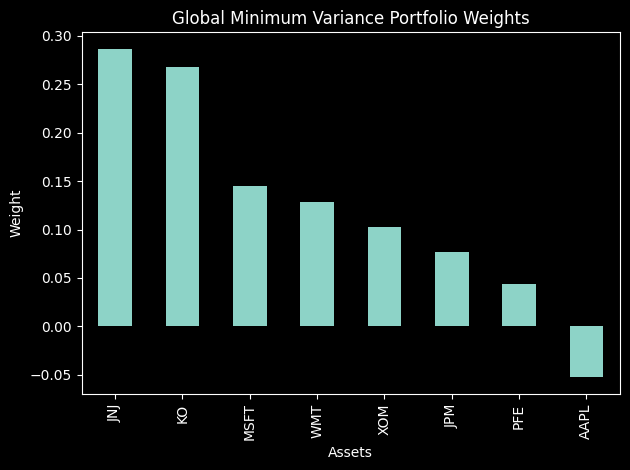

In [11]:
minimum_variance_weights.plot(
    kind="bar",
    title="Global Minimum Variance Portfolio Weights"
)

plt.ylabel("Weight")
plt.xlabel("Assets")
plt.tight_layout()
plt.show()